In [ ]:

import pandas as pd
import numpy as np


data_df = pd.read_csv('university_admission.csv')

data_df.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
data_df.describe()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,316.472000,107.193000,3.114000,3.374000,3.484000,8.57644,0.560000,0.72174
std,11.289494,6.079368,1.142939,0.990507,0.924986,0.60451,0.496635,0.14107
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.80000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.12750,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.56000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.04000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.92000,1.000000,0.97000


In [ ]:
data_columns = list(data_df.columns)
print(data_columns)

['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance_of_Admission']


===== Admitted/Not_adminted Count : =====
 Admitted
1    810
0    190
Name: count, dtype: int64


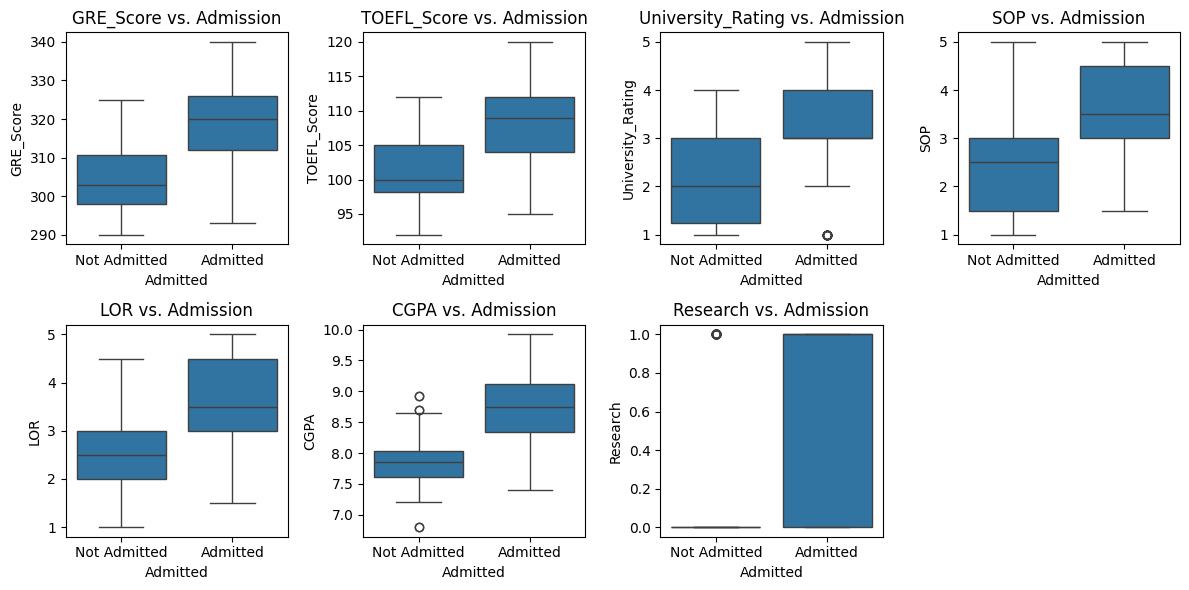

In [ ]:
df = data_df.copy()

threshold = 0.6

df['Admitted'] = (df['Chance_of_Admission'] >= threshold).astype(int)

df.head(20)

# check admitted/not admited number sum
print(f"===== Admitted/Not_adminted Count : =====\n {df['Admitted'].value_counts()}")

# plot plt boxplot of ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research'] against admitted
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
for col in ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research']:
    plt.subplot(2, 4, data_columns.index(col) + 1)
    sns.boxplot(x='Admitted', y=col, data=df)
    plt.title(f'{col} vs. Admission')
    plt.xticks([0, 1], ['Not Admitted', 'Admitted'])

plt.tight_layout()


def generate_insights(df):
    plt.figure(figsize=(12, 5))

    # Boxplot for CGPA (the most relevant feature)
    plt.subplot(1, 2, 1)
    sns.boxplot(x='Admitted', y='CGPA', data=df, palette='viridis')
    plt.title('CGPA Distribution by Admission Result')

    # Correlation Heatmap
    plt.subplot(1, 2, 2)
    sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.1f')
    plt.title('Feature Correlation Map')

    plt.tight_layout()
    plt.savefig('data_insights.png')
    print("Visualizations saved as 'data_insights.png'")

# generate_insights(df)

In [ ]:
# plot compare data and compare feature importance
data_df.isnull().sum()

,0
GRE_Score,0
TOEFL_Score,0
University_Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance_of_Admission,0


Text(0.5, 1.0, 'Correlation Factors Heat Map')

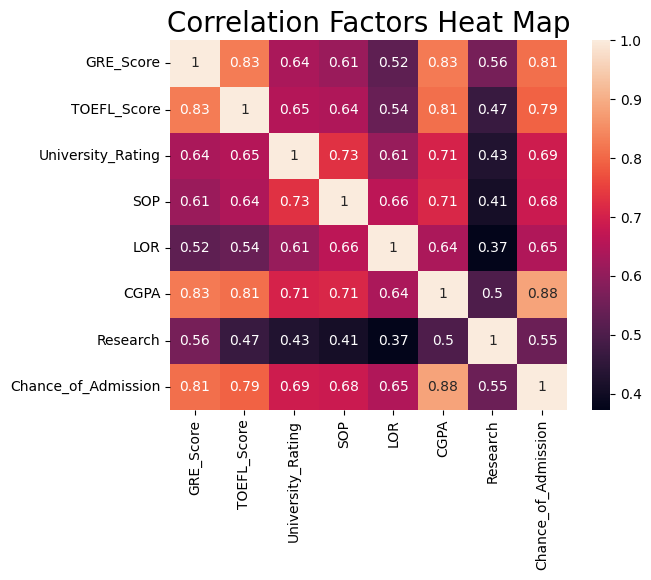

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# data_df['Program'] = label_encoder.fit_transform(data_df['Program'])


sns.heatmap(data_df.corr(), annot=True).set_title('Correlation Factors Heat Map', color='black', size='20')


In [ ]:
print("First 5 rows of the DataFrame:")
display(data_df.head())

First 5 rows of the DataFrame:


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
print("DataFrame information (columns, non-null counts, dtypes):")
display(data_df.info())

DataFrame information (columns, non-null counts, dtypes):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GRE_Score            1000 non-null   int64  
 1   TOEFL_Score          1000 non-null   int64  
 2   University_Rating    1000 non-null   int64  
 3   SOP                  1000 non-null   float64
 4   LOR                  1000 non-null   float64
 5   CGPA                 1000 non-null   float64
 6   Research             1000 non-null   int64  
 7   Chance_of_Admission  1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


None

In [ ]:
print("Descriptive statistics for numerical columns:")
display(data_df.describe())

Descriptive statistics for numerical columns:


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,316.472000,107.193000,3.114000,3.374000,3.484000,8.57644,0.560000,0.72174
std,11.289494,6.079368,1.142939,0.990507,0.924986,0.60451,0.496635,0.14107
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.80000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.12750,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.56000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.04000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.92000,1.000000,0.97000


In [ ]:
# %%writefile fip_project/pipeline.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('university_admission.csv')

# The dataset has a 'Chance of Admit' (0-1). We convert it to a classification (1 = Yes, 0 = No)
threshold = 0.60
df['Admitted'] = (df['Chance_of_Admission'] >= threshold).astype(int)

# Drop the original chance and Serial No if present
X = df.drop(['Chance_of_Admission ', 'Serial No.', 'Admitted'], axis=1, errors='ignore')
y = df['Admitted']


# 4. BUILD THE PIPELINE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)

# 5. SAVE MODEL & COLUMNS
joblib.dump(pipeline, 'fip_project/admission_pipeline.pkl')
joblib.dump(list(X.columns), 'fip_project/feature_names.pkl')
print("Pipeline trained and saved successfully!")


Pipeline trained and saved successfully!


In [ ]:
# Test and plot result
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

preprocessor = joblib.load('admission_pipeline.pkl')
features = joblib.load('feature_names.pkl')

predicton = preprocessor.predict(X_test)

# evaluate and plot
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"Accuracy: {accuracy_score(y_test, predicton)}")
print(classification_report(y_test, predicton))

#


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00       171

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



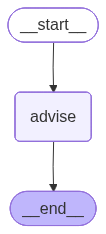

In [ ]:
# %%writefile fip_project/agent.py
import os
import joblib
from typing import TypedDict

import pandas as pd
from langgraph.graph import StateGraph, END
from typing import TypedDict
from langgraph.graph import StateGraph, END

try:
    from langchain_google_genai import ChatGoogleGenerativeAI
except:
    ! pip install langchain-google-genai
    from langchain_google_genai import ChatGoogleGenerativeAI


# --- CONFIG ---
# The GEMINI_API_KEY is already present in the kernel state.
os.environ['GOOGLE_API_KEY'] = GEMINI_API_KEY

model_pipeline = joblib.load('admission_pipeline.pkl')
features = joblib.load('feature_names.pkl')

# --- LANGGRAPH LOGIC ---
class AgentState(TypedDict):
    input_data: dict
    prediction: int
    probability: float
    explanation: str

def gemini_counselor(state: AgentState):
    llm = ChatGoogleGenerativeAI(
        model="gemini-1.5-flash",
        api_key=os.environ['GOOGLE_API_KEY'], # Use the environment variable
        temperature=0.5
    )

    status = "Admitted" if state['prediction'] == 1 else "Not Admitted"

    prompt = f"""
    Context: You are an AI Academic Advisor for FlexiSAF.
    Student Data: {state['input_data']}
    Result: {status} (Confidence: {state['probability']}%)

    Instruction: Write a 3-sentence professional explanation.
    Explain how their CGPA and GRE scores specifically affected this outcome.
    """
    response = llm.invoke(prompt)
    return {"explanation": response.content}

# Compile Graph
workflow = StateGraph(AgentState)
workflow.add_node("advise", gemini_counselor)
workflow.set_entry_point("advise")
workflow.add_edge("advise", END)
graph = workflow.compile()

from IPython import display
from IPython.display import Image

display.display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# %%writefile fip_project/UI_app.py
import os
import joblib
import pandas as pd
import streamlit as st

# from agent import graph

model_pipeline = joblib.load('admission_pipeline.pkl')
features = joblib.load('feature_names.pkl')


# --- STREAMLIT UI ---
st.set_page_config(page_title="FlexiSAF Admisssion AI", layout="centered")
st.title("🎓 Admission Success Predictor")

with st.sidebar:
    st.header("Enter Student Metrics")
    gre = st.number_input("GRE Score", 260, 340, 310)
    toefl = st.number_input("TOEFL Score", 0, 120, 100)
    rating = st.slider("University Rating", 1, 5, 3)
    sop = st.slider("SOP Strength", 1.0, 5.0, 3.5)
    lor = st.slider("LOR Strength", 1.0, 5.0, 3.5)
    cgpa = st.number_input("CGPA", 0.0, 10.0, 8.5)
    research = st.radio("Research Experience?", [0, 1], format_func=lambda x: "Yes" if x==1 else "No")

if st.button("Analyze Application"):
    # 1. Prediction
    input_dict = {
        'GRE_Score': gre, 'TOEFL_Score': toefl, 'University_Rating': rating,
        'SOP': sop, 'LOR': lor, 'CGPA': cgpa, 'Research': research
    }
    input_df = pd.DataFrame([input_dict])

    prob = model_pipeline.predict_proba(input_df)[0][1]
    pred = 1 if prob >= 0.5 else 0

    # 2. GenAI Explanation
    with st.spinner("Consulting AI Counselor..."):
        result = graph.invoke({
            "input_data": input_dict,
            "prediction": pred,
            "probability": round(prob * 100, 2)
        })

    # 3. UI Display
    st.divider()
    col1, col2 = st.columns(2)

    with col1:
        st.metric("Success Probability", f"{round(prob * 100, 2)}%")
        if pred == 1:
            st.success("High Admission Probability!")
        else:
            st.warning("Low Admission Probability.")

    with col2:
        st.subheader("AI Insight")
        st.write(result['explanation'])

    # Show Feature Importance Chart
    st.subheader("Feature Impact Analysis")
    importances = model_pipeline.named_steps['classifier'].feature_importances_
    feat_imp = pd.Series(importances, index=features).sort_values()
    st.bar_chart(feat_imp)

In [ ]:
!streamlit run fip_project/UI_app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.60.43.114:8501

